---
title: "Predicting from Images and Tabular Data Together"
description: "Put chest X-rays in a DataFrame column next to patient fields, and let TabPFN predict from both with TabPFNWithImages from tabpfn-extensions."
icon: "images"
cookbookTags:
  - extensions
  - classification
  - images
authors:
  - name: Tuana Çelik
    linkedin: https://www.linkedin.com/in/tuanacelik/
    twitter: https://x.com/tuanacelik
  - name: Alan Arazi
    linkedin: https://www.linkedin.com/in/alanarazi1989/
    twitter: https://x.com/AlanArazi1536
---

Real-world tables aren't strictly confined to just numbers and categories. Every so often, they are augmented with richer, unstructured modalities: a product listing is paired with a photo, a patient's record includes a diagnostic scan, or a property listing features a gallery of rooms. However, even though these visual elements occasionally surface alongside structured data, current tabular foundation models like TabPFN have no native way to actually "see" them.

This cookbook shows the simplest bridge: `TabPFNWithImages` from `tabpfn-extensions`. You keep your dataset as it is, tell the wrapper which column holds images, and it turns each picture into a handful of numeric features before TabPFN sees it.

The motivation comes from the [MulTaBench paper](https://arxiv.org/abs/2605.10616), which curates 40 datasets where combining tabular fields with an image or a text provably beats either modality alone. We use one of its image tasks, CheXpert: decide whether a chest X-ray shows cardiomegaly, an enlarged heart, from the scan together with the patient's sex and age and the view of the scan. The full MulTaBench task has 46,437 X-rays and 17 tabular columns, most of them other radiology labels. To keep the notebook quick we use a toy version published on Kaggle: a random 5,000-row subsample that keeps only the four patient fields and the target. The scores below are for this toy task and are not comparable with the benchmark's numbers.

## Setup

The image extension for TabPFN ships in `tabpfn-extensions[image]`.

Two things need a one-time acceptance. The image encoder's weights, DINOv3, are gated on the Hugging Face Hub: accept the license on the [model page](https://huggingface.co/facebook/dinov3-vits16-pretrain-lvd1689m), then run `hf auth login` in a terminal or set the `HF_TOKEN` environment variable. The local `tabpfn` package also asks you to accept its license the first time it downloads model weights; in a notebook, set `TABPFN_TOKEN` to an API key from the [TabPFN platform](https://platform.priorlabs.ai/account/api-keys).

A GPU is recommended for the full toy subsample: embedding 5,000 X-rays and fitting TabPFN on 3,750 rows is a few minutes on a T4 and much longer on a CPU. Without one, the notebook runs on a 300-row sample so every cell finishes quickly. Set `N_ROWS = None` to use everything.

In [ ]:
%pip install -q "tabpfn-extensions[image] @ git+https://github.com/PriorLabs/tabpfn-extensions" kagglehub matplotlib

In [1]:
import os

try:
    from google.colab import userdata
except ImportError:
    pass
else:
    for name in ("HF_TOKEN", "TABPFN_TOKEN"):
        if not os.environ.get(name):
            try:
                os.environ[name] = userdata.get(name)
            except userdata.SecretNotFoundError:
                pass

In [2]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import torch
from PIL import Image
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

from tabpfn_extensions import TabPFNClassifier
from tabpfn_extensions.image import TabPFNWithImages

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_ROWS = None if DEVICE == "cuda" else 300  # full subsample on a GPU, a quick sample on CPU
print(f"device: {DEVICE}, rows: {'all' if N_ROWS is None else N_ROWS}")

device: cuda, rows: all


## Load and inspect the data

We fetch the toy CheXpert subsample from Kaggle. Each row is one chest X-ray study: the patient's sex and age, whether the view is frontal or lateral and, for frontal views, whether it was taken AP or PA, `X-Ray Image`, which is the path of the scan relative to the archive, and the target `Cardiomegaly`, coded 1 for positive, 0 for negative and -1 when the radiology report was uncertain. `AP/PA` is blank for lateral views; TabPFN handles missing values natively, so we leave it as it is.

In [3]:
root = Path(kagglehub.dataset_download("chico89/multabench-chexpert-toy-subsampled"))
data = pd.read_csv(root / "data.csv")
if N_ROWS is not None:
    data = data.sample(n=N_ROWS, random_state=0).reset_index(drop=True)
print(data.shape)
data.head()

100%|██████████| 241M/241M [00:07<00:00, 35.9MB/s]

Extracting files...


(5000, 6)


,Sex,Age,Frontal/Lateral,AP/PA,X-Ray Image,Cardiomegaly
0,Female,46,Lateral,NaN,images/train_patient07247_study1_view2_lateral...,0.0
1,Male,55,Frontal,AP,images/train_patient29065_study9_view1_frontal...,1.0
2,Female,81,Frontal,AP,images/train_patient42182_study6_view1_frontal...,1.0
3,Male,84,Lateral,NaN,images/train_patient16258_study1_view2_lateral...,0.0
4,Female,79,Lateral,NaN,images/train_patient04768_study2_view2_lateral...,-1.0


Here are the first three X-rays, so you can see what TabPFN is about to look at. They are grayscale scans of roughly 390 by 320 pixels; the encoder converts them to RGB itself.

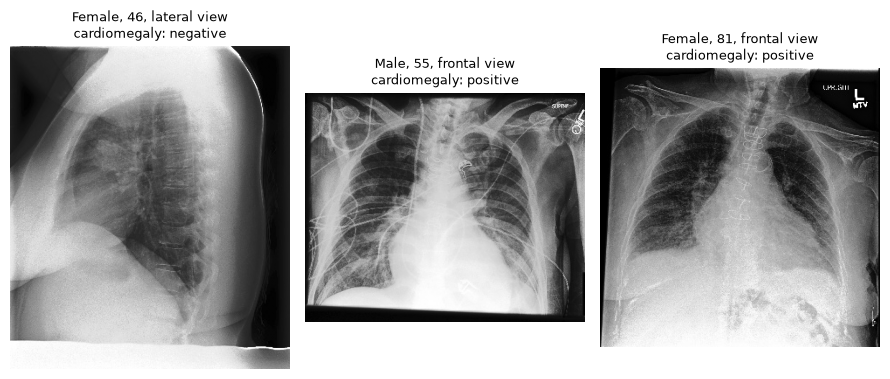

In [4]:
LABELS = {1.0: "positive", 0.0: "negative", -1.0: "uncertain"}

fig, axes = plt.subplots(1, 3, figsize=(9, 3.8))
for ax, (_, row) in zip(axes, data.head(3).iterrows()):
    ax.imshow(Image.open(root / row["X-Ray Image"]), cmap="gray")
    ax.set_title(
        f"{row['Sex']}, {row['Age']}, {row['Frontal/Lateral'].lower()} view\n"
        f"cardiomegaly: {LABELS[row['Cardiomegaly']]}",
        fontsize=9,
    )
    ax.axis("off")
plt.tight_layout()
plt.show()

The image column just needs the absolute path of each file. We rename it `image`, pop `Cardiomegaly` as the target so it stays unknown for prediction, and split the dataset 75/25, stratified so the three classes keep their proportions in both halves.

In [5]:
y = data.pop("Cardiomegaly").astype(int)
data["image"] = [str(root / path) for path in data.pop("X-Ray Image")]
tabular = [column for column in data.columns if column != "image"]

X_train, X_test, y_train, y_test = train_test_split(
    data, y, test_size=0.25, random_state=0, stratify=y
)
print(f"tabular columns: {tabular}")
print(f"train: {len(X_train)} rows, test: {len(X_test)} rows")
X_train.head(3)

tabular columns: ['Sex', 'Age', 'Frontal/Lateral', 'AP/PA']
train: 3750 rows, test: 1250 rows


,Sex,Age,Frontal/Lateral,AP/PA,image
1524,Male,63,Lateral,NaN,/mnt/local-ssd/kagglehub/datasets/chico89/mult...
4697,Female,48,Frontal,AP,/mnt/local-ssd/kagglehub/datasets/chico89/mult...
1366,Female,27,Frontal,AP,/mnt/local-ssd/kagglehub/datasets/chico89/mult...


## How it works

Each image is turned into one vector by a frozen, pretrained image encoder. The encoder is `DINOv3 ViT-S/16`, a small Vision Transformer, which is a neural network that reads an image as a grid of patches and was trained without labels to produce a useful summary of any picture. The summary is its "CLS embedding": one vector of 384 numbers per image.

Those 384 numbers are standardised and reduced to 30 with principal component analysis (PCA). TabPFN then sees 30 ordinary numeric columns next to the original ones. Nothing is trained along the way: the encoder is frozen, and TabPFN does in-context learning in a single forward pass over the training rows. The whole thing stays fast and hard to overfit.

## Baseline: tabular fields only

*Plain TabPFN on sex, age and view.*

We start without the X-ray, so we know what the tabular fields alone are worth. The target has three classes, so we score with macro-averaged one-vs-rest ROC AUC, where 0.5 is random guessing and 1.0 is perfect.

In [6]:
results = {}


def auc(model, X):
    return roc_auc_score(y_test, model.predict_proba(X), multi_class="ovr")


classifier = TabPFNClassifier()
classifier.fit(X_train[tabular], y_train)
results["tabular only"] = auc(classifier, X_test[tabular])

In [7]:
print(f"ROC AUC, tabular only: {results['tabular only']:.3f}")

ROC AUC, tabular only: 0.621


## Picture only

`TabPFNWithImages` takes the estimator to wrap and `image_features_indices`, the positions of the image columns in the dataset you pass to `fit`, just like TabPFN's own `categorical_features_indices`. Here the frame has one column, so the index is 0. The first call downloads the encoder weights.

> You'll need to agree to the model license for `DINOv3` on Hugging Face to use it.

In [8]:
picture_only = TabPFNWithImages(TabPFNClassifier(), image_features_indices=[0])
picture_only.fit(X_train[["image"]], y_train)
results["picture only"] = auc(picture_only, X_test[["image"]])

In [9]:
print(f"ROC AUC, picture only: {results['picture only']:.3f}")

ROC AUC, picture only: 0.698


## Tabular + picture

Now the frame has the four tabular columns followed by `image`, so the image column sits at position `len(tabular)`. Everything else is unchanged.

In [10]:
columns = [*tabular, "image"]
both = TabPFNWithImages(TabPFNClassifier(), image_features_indices=[len(tabular)])
both.fit(X_train[columns], y_train)
results["tabular + picture"] = auc(both, X_test[columns])

In [11]:
print(f"ROC AUC, tabular + picture: {results['tabular + picture']:.3f}")

ROC AUC, tabular + picture: 0.703


In [12]:
scores = pd.Series(results, name="ROC AUC").to_frame()
display(scores.round(3))

,ROC AUC
tabular only,0.621
picture only,0.698
tabular + picture,0.703


On this toy task the X-ray alone is well ahead of the four patient fields alone, and the combined model comes out on top. MulTaBench only includes tasks where "both beats either" held across several different learners on the full data, so this pattern is what the benchmark was built to isolate. For more tasks, the [paper](https://arxiv.org/abs/2605.10616) and the [MulTaBench datasets on Kaggle](https://www.kaggle.com/chico89/datasets) have 20 image-tabular tasks, all downloadable with `kagglehub` like the one used here.